# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Chapter 22:TinyStories**

### **Section 1: npyファイルへの変換**

このノートブックにはGPUは必要ありません。CPUを使用しましょう。

ランタイムをCPUに設定しましょう。

In [ ]:
import torch
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # 現在使用デバイス（GPUまたはCPU）
print(device_type)

**`Check Point`**  
<label><input type="checkbox">ランタイムがcpuに設定されていることを確認した<br></label>  

質問です！

検証誤差を下げる方法にはどうすればいいでしょうか？

もちろんいろんな回答があると思います。

1つとてもシンプルな解決策は、そもそも学習するデータセットを簡単にするということです。

そこで登場するのが昔話のデータセットである [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories)　です。

これはGPT3.5によって合成された昔話の大規模データセットです。

finewebデータセットのようなweb上のブログやwikipediaのような百科事典の続きを予測するよりも、昔話の続きを予測する方が簡単だと思いませんか？実際にそうです。

finewebデータセット相手だとColabのT4 GPUではあまり勝負にならないのですが、この TinyStoriesデータセットなら十分な性能が得られます。

ここからは TinyStoriesが標準のデータセットとなります、それではレッツゴー！

In [ ]:
!wget https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStories-train.txt

In [ ]:
!head /content/TinyStories-train.txt

1つ目の昔話を読んでみましょう。読みやすいように適宜改行を追加しています。

```plain
One day, a little girl named Lily found a needle in her room.
She knew it was difficult to play with it because it was sharp.
Lily wanted to share the needle with her mom, so she could sew a button on her shirt.
Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?"
Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."
Together, they shared the needle and sewed the button on Lily's shirt.
It was not difficult for them because they were sharing and helping each other.
After they finished, Lily thanked her mom for sharing the needle and fixing her shirt.
They both felt happy because they had shared and worked together.
<|endoftext|>
```

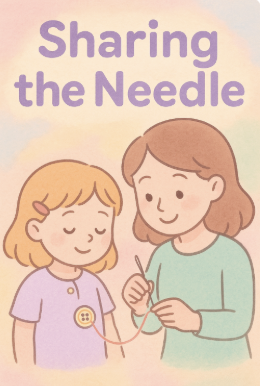

ChatGPTが書いた昔話なので、とてもミステリアスです。

最高ですね。

読んでもらってわかる通り、とても平易な英語で書かれています。

学習データセットとしては極めて学習しやすいグループに属します。


なお、<|endoftext|>が文章の最後に来ています。

詳しい理由は省略しますが、本来は<|endoftext|>が文章の最初にある方が好ましいです。

とはいえ、今回は大きな問題ではないので、気にせず進めていきます。

億単位の文字がある`/content/TinyStories-train.txt`を、1,000万文字のチャンクでencodeしていきます。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`tiktoken`　`openai`　`get_encoding`　`"gpt2"`　`encoder`　`decoder`　`encode`　`decode`,　`output_pt_path`　`input_text_path`　`"w"`　`"r"`　`"ab"`　`"wb"`　`"utf-8"`　`chunk_size`　`chunk`　`torch.tensor`　`tokens`　`np.int32`　`np.int8`　`tofile`　`arr`　`flush()`　`finish()`　`total_tokens`

In [ ]:
input_text_path = "/content/TinyStories-train.txt"
output_pt_path = "/content/TinyStories-train.pt"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

all_token_ids = []
total_tokens = 0

with open(input_text_path, "r", encoding="utf-8") as f:
    while True:
        chunk = f.read(chunk_size)
        if not chunk:
            break
        tokens = encoder.encode(chunk, allowed_special="all")
        all_token_ids.extend(tokens)
        total_tokens += len(tokens)
        print(f"processed {total_tokens:,} tokens...")

token_ids_tensor = torch.tensor(all_token_ids, dtype=torch.int32)
torch.save(token_ids_tensor, output_pt_path)
print(f"done: {total_tokens:,} tokens saved")


<details>
<summary>クリックして答えを表示/非表示</summary>

```python
import tiktoken
import os

input_text_path = "/content/TinyStories-train.txt"
output_pt_path = "/content/TinyStories-train.bin"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

# 全トークン数をカウントする変数
total_tokens = 0

# テキストファイルを開き、トークン化 → バイナリ保存
with open(input_text_path, "r", encoding="utf-8") as f:
    with open(output_pt_path, "ab") as out:
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = f.read(chunk_size)

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = encoder.encode(chunk, allowed_special="all")

            # torch Tensorに変換（型をint32に）
            arr = torch.tensor(tokens, dtype=torch.int32)

            # バイナリファイルに書き込む
            arr.tofile(out)

            # ファイルへの書き込みを確実に反映
            out.flush()

            # 処理済みトークン数を更新
            total_tokens += len(arr)

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")
```

3. `.bin` を NumPy形式（.pt） に変換  

バイナリファイルのままでもインデックスアクセスはできますが、numpyファイルの方が一般的なので、numpyファイルに変更します。

優位点：numpyファイルは`int32`のような型情報をファイル内部に含むため、他人が受け取った時にわかりやすい。

バイナリファイルでは、これは`int32`だという情報がファイル内に含まれないので、READMEまたはファイル名に記載するなどの方法が取られます。

```python
関数: torch.load
引数: file=バイナリファイルのパス, dtype=データ型（ここではnp.int32）
```

* `torch.load()` は、バイナリファイルから直接 torch Tensorを生成する関数です。
* `dtype=np.int32`：バイナリデータを `int32`（4バイト整数）として読み取ります。
* 数値の生データ（例：トークンIDなど）を高速に読み込む用途で使われます。

In [ ]:
# .ptファイルから torch Tensor を読み込む
data = torch.load(output_pt_path, map_location="cpu") # TODO: torch.load(file=ファイルパス, map_location="cpu") を適用
print("読み込んだトークン数:", len(data))


```python
関数: torch.save
引数: file=保存先のパス, arr=保存するtorch Tensor
```

* `torch.save()` は、torch Tensorを `.pt` 形式で保存する関数です。
* `.pt` 形式は、torch Tensorを効率的に格納・読み出しできる公式フォーマットです。
* `file=token_path`: 保存先ファイルのパス。

In [ ]:
# 2️⃣ 正しい .pt フォーマットで保存
token_path = "/content/TinyStories-train.pt"
torch.save(data, token_path) # TODO: 関数(引数)

4. `torch.load(..., map_location="cpu", mmap=True)` で メモリマップ読み込み

```python
関数: torch.load
引数: file=読み込む .pt ファイルのパス, map_location="cpu", mmap=True
```

* `torch.load()` は `.pt` 形式で保存された torch Tensorを読み込む関数です。
* `map_location="cpu", mmap=True` を指定することで、**メモリマップ**（memory-mapping）が有効になります。

  * これにより、ファイル全体を一度に読み込まず、必要な部分だけを読み込むことができ、RAMの節約になります。
* `tokens = torch.load(...)` により、`.pt` ファイルからトークン列（配列）を効率的に読み出します。

In [ ]:
tokens = torch.load(token_path, map_location="cpu", mmap=True) # TODO: torch.load(ファイルパス, map_location="cpu", mmap=True) を適用
sample_tokens = tokens[100:200]
print(sample_tokens)


**Section 1: npyファイルの作成** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: HuggingFaceへの保存**

今後もこの`TinyStories-train.pt`ファイルは使うので、HuggingFaceに保存します。

しかしHuggingFaceの仕様は非常に頻繁に変わるので、これが作成された2025年11月以降はうまくいかないかもしれません。

うまくいかなかった場合は仕様変更の問題なので、諦めてください。

認証まわりが関わる部分をデバッグするのはあまり初心者フレンドリーではありません。

npyファイルは以下のリポジトリなどで提供しているので、今回できなくても問題はありません。

https://huggingface.co/datasets/HayatoHongoEveryonesLLM/TinyStories-test/tree/main



#### 方法1: HF APIを用いる

HuggingFaceアカウントの作成

⚠️ 44:16 ~ 47: 05 の部分だけ見てください！

[Watch the video!](https://youtu.be/qkS_Zc6uvbo)
- 3 minutes, no-sound
- Video ID: qkS_Zc6uvbo

---

次に、Datasetのリポジトリを作成します。

[Watch the video!](https://youtu.be/XiwL9uH7cbk)
- 50 seconds, no-sound
- Video ID: XiwL9uH7cbk

---

最後に、アクセストークンを発行します。

以下のサイトにアクセスしてください。

https://huggingface.co/settings/tokens

[Watch the video!](https://youtu.be/LuqQUi7Y47I)
- 45 seconds, no-sound
- Video ID: LuqQUi7Y47I


In [ ]:
# HF_TOKENは https://huggingface.co/settings/tokens に自分のHFアカウントでログインして入手する。

from huggingface_hub import login
login()

```python
クラス: HfApi
引数：なし
```

* `HfApi` は、Hugging Face Hub 上のモデルやデータセット、スペース、ユーザー情報などを操作するためのクラスです。
* `HfApi()` によって、このAPIクライアントのインスタンスを作成します。
* 作成した `api` を通して、リポジトリの作成や削除、アップロードなどの操作が可能になります。



In [ ]:
# 事前にデータセットのレポジトリを作成してください。

from huggingface_hub import HfApi

# Hugging Face Hubと対話するためのAPIインスタンスの作成
api = HfApi()  # TODO:  HfApiクラスのインスタンスを作成

HuggingFace API は仕様変更が激しく、認証エラーが極めて発生しやすいです。

うまくいかなくても大丈夫です。スキップして方法2を用いてください。

In [ ]:
api.upload_file(
    path_or_fileobj="/content/TinyStories-train.pt",
    repo_id="HayatoHongoEveryonesLLM/TinyStories-test",  # TODO: "YOUR_USERNAME/YOUR_REPO_NAME" で指定する。最後に ","を忘れないこと。
    repo_type="dataset", # データセットリポジトリかモデルリポジトリか
    path_in_repo="TinyStories-train.pt"   # リポジトリ上に保存するためのファイル名
)

#### **方法2: ローカルを使う（方法1がうまくいかなかった方向け）**

HuggingFaceの仕様は頻繁に変わるので、うまくいかなかった方向けに別の方法を紹介します。

まず、ファイルをローカルのパソコンにダウンロードします。

ローカルのパソコンからHuggingFaceにアップロードしましょう。

通信が重たいので、Wifi環境でお願いします。

（方法1がうまくいかず、wifiがない方は次のセクションへ進んでください。）

ディスクサイズの1.8GBのファイルですが、ダウンロードには非常に時間がかかります。

10分ほど待ってください。

In [ ]:
from google.colab import files
files.download('/content/TinyStories-train.pt')

次に、ダウンロードしたファイルをアップロードします。

[Watch the video!](https://youtu.be/IP9Mcq9hWx4)
- 4 minutes, no-sound
- Video ID: IP9Mcq9hWx4

**Section 2: HuggingFaceへの保存** <label><input type="checkbox"> Mark as Done</label>

さあ、面倒なことはここまで！

モデル学習notebookに進んでください！

LLMをつくろう！